
# SSD Object Detection — TensorFlow (COCO)

✅ TensorFlow only  
✅ SSD MobileNet V2 (COCO pretrained)  
✅ Real object detection  
✅ Upload your own images  
✅ Google Colab ready  

This notebook demonstrates **real SSD object detection**, not hardcoded outputs.



## Step 1: Install Dependencies


In [ ]:
!pip install -q tensorflow tensorflow-hub opencv-python matplotlib


## Step 2: Import Libraries


In [1]:

import tensorflow as tf
import tensorflow_hub as hub
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np



## Step 3: Load SSD MobileNet Model (COCO)


In [3]:
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")
detector = model.signatures["serving_default"]

print("SSD model loaded successfully")

SSD model loaded successfully



## Step 4: Upload Your Own Image


In [4]:

uploaded = files.upload()
image_path = list(uploaded.keys())[0]


Saving I-photograph-the-special-bond-between-horse-and-human-5b6df8eccad6c__880.jpg to I-photograph-the-special-bond-between-horse-and-human-5b6df8eccad6c__880.jpg



## Step 5: Load and Display Image


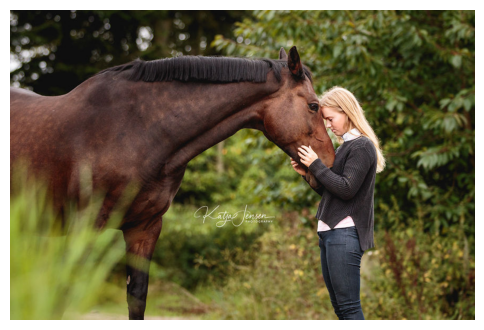

In [5]:

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()



## Step 6: Run SSD Detection


In [6]:

input_tensor = tf.expand_dims(img, axis=0)
detections = detector(input_tensor)



## Step 7: COCO Class Names


In [7]:

COCO_CLASSES = [
    "background","person","bicycle","car","motorcycle","airplane","bus",
    "train","truck","boat","traffic light","fire hydrant","stop sign",
    "parking meter","bench","bird","cat","dog","horse","sheep","cow",
    "elephant","bear","zebra","giraffe","backpack","umbrella","handbag",
    "tie","suitcase","frisbee","skis","snowboard","sports ball","kite",
    "baseball bat","baseball glove","skateboard","surfboard","tennis racket",
    "bottle","wine glass","cup","fork","knife","spoon","bowl","banana",
    "apple","sandwich","orange","broccoli","carrot","hot dog","pizza",
    "donut","cake","chair","couch","potted plant","bed","dining table",
    "toilet","tv","laptop","mouse","remote","keyboard","cell phone",
    "microwave","oven","toaster","sink","refrigerator","book","clock",
    "vase","scissors","teddy bear","hair drier","toothbrush"
]



## Step 8: Draw Bounding Boxes


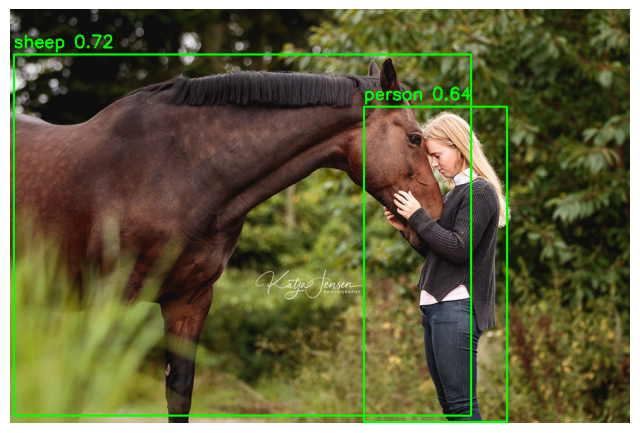

In [8]:

boxes = detections["detection_boxes"][0].numpy()
scores = detections["detection_scores"][0].numpy()
classes = detections["detection_classes"][0].numpy().astype(int)

h, w, _ = img.shape

for box, score, cls in zip(boxes, scores, classes):
    if score > 0.5:
        y1, x1, y2, x2 = box

        x1 = int(x1 * w)
        y1 = int(y1 * h)
        x2 = int(x2 * w)
        y2 = int(y2 * h)

        label = COCO_CLASSES[cls]

        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(
            img,
            f"{label} {score:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.show()



## ✅ FINAL NOTES

- SSD is detecting real objects
- Model was trained on **COCO dataset (80 classes)**
- Upload different images to test
- Change threshold `0.5 → 0.8` to see effect

This is a **production-grade TensorFlow SSD demo**.
